  TRADING ALGORITHMIQUE — APPLE (AAPL)

  Donnees chargees :
  Periode    : 2006-10-02 -> 2011-12-30
  Nb de jours: 1323
  Prix debut : $2.25
  Prix fin   : $12.15
  Performance: 441.0%

  STRATEGIE : Croisement MM 40j / MM 100j
  Signaux d'achat  : 6
  Signaux de vente : 6

  BACKTESTING
  Capital initial  : $10,000
  Capital final    : $10,681
  Performance      : +6.8%

  KPIs DE PERFORMANCE
  Sharpe Ratio     : 0.735
  Max Drawdown     : -3.2%
  CAGR             : 1.3% par an


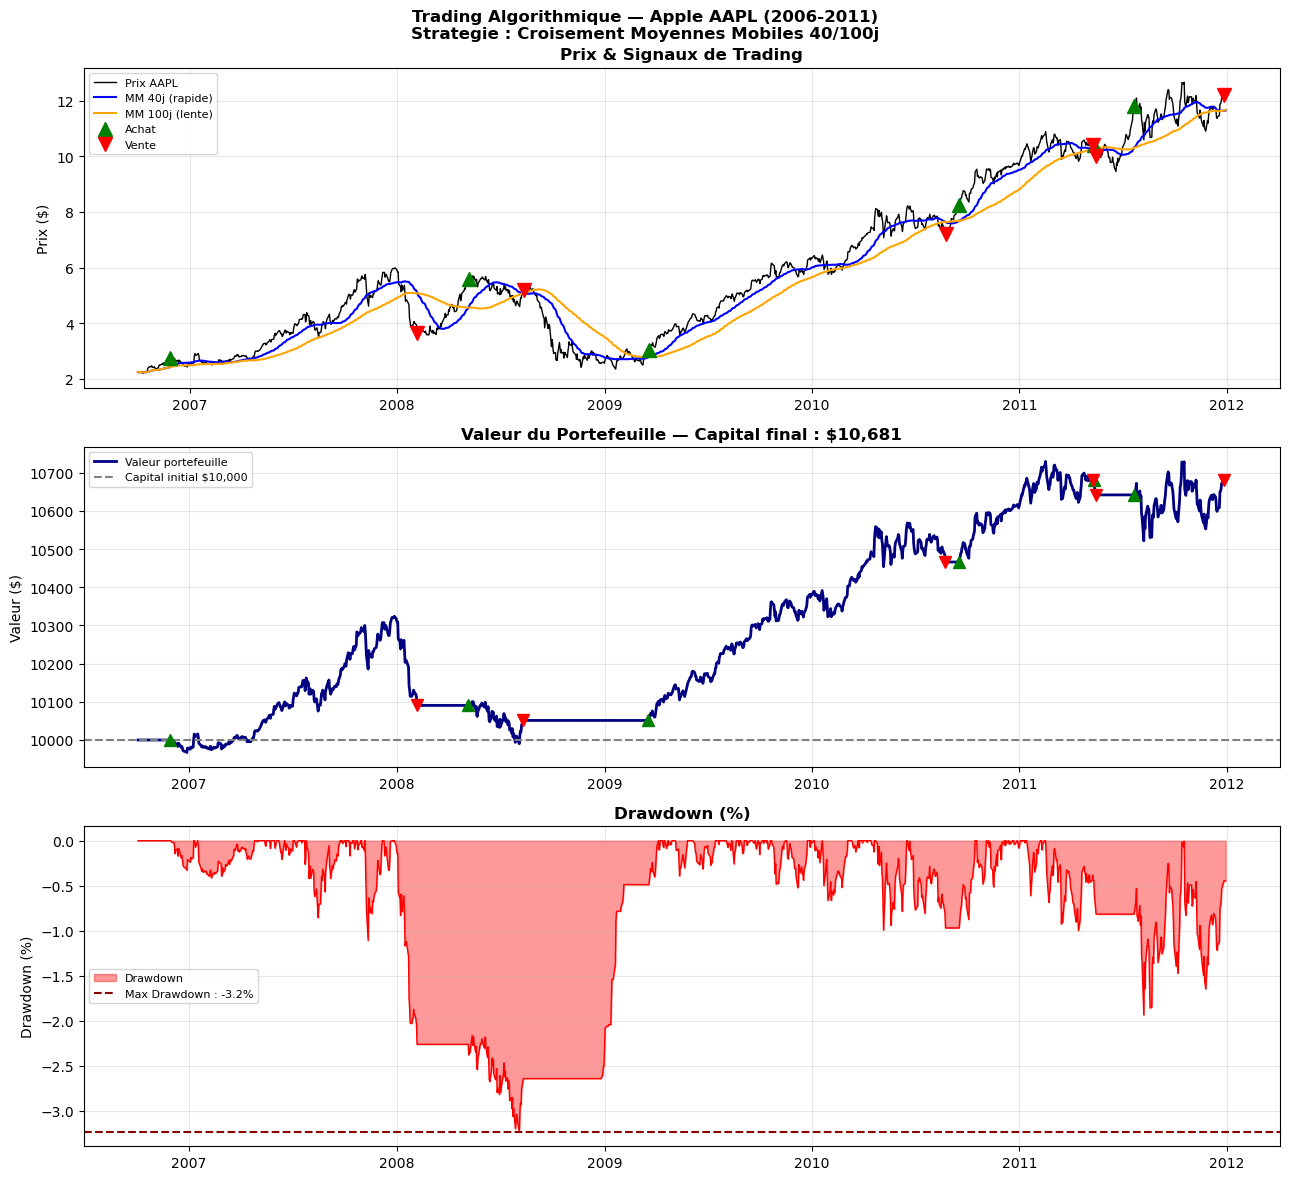


Graphiques sauvegardes !

  SYNTHESE FINALE
  Action          : Apple AAPL
  Periode         : 2006 -> 2011
  Strategie       : MM 40j / MM 100j
  Capital initial : $10,000
  Capital final   : $10,681
  Performance     : +6.8%
  Sharpe Ratio    : 0.735
  Max Drawdown    : -3.2%
  CAGR            : 1.3% par an


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. CHARGEMENT DES DONNEES

aapl = pd.read_csv('aapl_ohlc.csv', header=0, index_col='Date', parse_dates=True)

print("=" * 55)
print("  TRADING ALGORITHMIQUE — APPLE (AAPL)")
print("=" * 55)
print(f"\n  Donnees chargees :")
print(f"  Periode    : {aapl.index[0].date()} -> {aapl.index[-1].date()}")
print(f"  Nb de jours: {len(aapl)}")
print(f"  Prix debut : ${aapl['Close'].iloc[0]:.2f}")
print(f"  Prix fin   : ${aapl['Close'].iloc[-1]:.2f}")
print(f"  Performance: {((aapl['Close'].iloc[-1]/aapl['Close'].iloc[0])-1)*100:.1f}%")

# 2. STRATEGIE — CROISEMENT DE MOYENNES MOBILES

fast_window = 40
slow_window = 100

signals = aapl[['Close']].copy()
signals['fast_mavg'] = aapl['Close'].rolling(window=fast_window, min_periods=1).mean()
signals['slow_mavg'] = aapl['Close'].rolling(window=slow_window, min_periods=1).mean()

signals['positions'] = 0.0
signals.loc[signals.index[fast_window:], 'positions'] = np.where(
    signals['fast_mavg'].iloc[fast_window:] > signals['slow_mavg'].iloc[fast_window:], 1.0, 0.0
)
signals['signal'] = signals['positions'].diff()

nb_achats = len(signals[signals['signal'] == 1.0])
nb_ventes = len(signals[signals['signal'] == -1.0])

print(f"\n  STRATEGIE : Croisement MM {fast_window}j / MM {slow_window}j")
print(f"  Signaux d'achat  : {nb_achats}")
print(f"  Signaux de vente : {nb_ventes}")

# 3. BACKTESTING

initial_capital = 10000.0
nb_actions = 100

positions = pd.DataFrame(index=signals.index).fillna(0.0)
positions['AAPL'] = nb_actions * signals['positions']

portfolio = pd.DataFrame(index=signals.index).fillna(0.0)
portfolio['holdings'] = positions['AAPL'] * aapl['Close']

pos_diff   = positions.diff()
cash_moves = -(pos_diff['AAPL'] * aapl['Close']).cumsum()
portfolio['cash']    = initial_capital + cash_moves
portfolio['total']   = portfolio['cash'] + portfolio['holdings']
portfolio['returns'] = portfolio['total'].pct_change()

perf = (portfolio['total'].iloc[-1] / initial_capital - 1) * 100

print(f"\n  BACKTESTING")
print(f"  Capital initial  : ${initial_capital:,.0f}")
print(f"  Capital final    : ${portfolio['total'].iloc[-1]:,.0f}")
print(f"  Performance      : {perf:+.1f}%")

# 4. KPIs

returns = portfolio['returns'].dropna()
sharpe  = np.sqrt(252) * (returns.mean() / returns.std())

window      = 252
rolling_max = portfolio['total'].rolling(window, min_periods=1).max()
drawdown    = portfolio['total'] / rolling_max - 1.0
max_drawdown = drawdown.min()

days = (portfolio.index[-1] - portfolio.index[0]).days
cagr = ((portfolio['total'].iloc[-1] / portfolio['total'].iloc[1]) ** (365.0/days)) - 1

print(f"\n  KPIs DE PERFORMANCE")
print(f"  Sharpe Ratio     : {sharpe:.3f}")
print(f"  Max Drawdown     : {max_drawdown*100:.1f}%")
print(f"  CAGR             : {cagr*100:.1f}% par an")

# 5. GRAPHIQUES

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle("Trading Algorithmique — Apple AAPL (2006-2011)\nStrategie : Croisement Moyennes Mobiles 40/100j",
             fontsize=12, fontweight='bold')

# Graphique 1 : Prix + Moyennes mobiles + Signaux
ax1 = axes[0]
ax1.plot(aapl['Close'],        color='black',  lw=1,   label='Prix AAPL')
ax1.plot(signals['fast_mavg'], color='blue',   lw=1.5, label='MM 40j (rapide)')
ax1.plot(signals['slow_mavg'], color='orange', lw=1.5, label='MM 100j (lente)')

ax1.plot(signals.loc[signals.signal == 1.0].index,
         aapl['Close'][signals.signal == 1.0],
         '^', markersize=10, color='green', label='Achat')
ax1.plot(signals.loc[signals.signal == -1.0].index,
         aapl['Close'][signals.signal == -1.0],
         'v', markersize=10, color='red', label='Vente')

ax1.set_title('Prix & Signaux de Trading', fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Graphique 2 : Valeur du portefeuille
ax2 = axes[1]
ax2.plot(portfolio['total'], color='navy', lw=2, label='Valeur portefeuille')
ax2.axhline(y=initial_capital, color='gray', linestyle='--', label=f'Capital initial ${initial_capital:,.0f}')
ax2.plot(portfolio.loc[signals.signal == 1.0].index,
         portfolio['total'][signals.signal == 1.0],
         '^', markersize=8, color='green')
ax2.plot(portfolio.loc[signals.signal == -1.0].index,
         portfolio['total'][signals.signal == -1.0],
         'v', markersize=8, color='red')
ax2.set_title(f'Valeur du Portefeuille — Capital final : ${portfolio["total"].iloc[-1]:,.0f}', fontweight='bold')
ax2.set_ylabel('Valeur ($)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Graphique 3 : Drawdown
ax3 = axes[2]
ax3.fill_between(drawdown.index, drawdown*100, 0, color='red', alpha=0.4, label='Drawdown')
ax3.plot(drawdown*100, color='red', lw=1)
ax3.axhline(y=max_drawdown*100, color='darkred', linestyle='--',
            label=f'Max Drawdown : {max_drawdown*100:.1f}%')
ax3.set_title('Drawdown (%)', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('TradingAlgorithmique_Graphiques.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphiques sauvegardes !")

# 6. SYNTHESE

print(f"\n{'='*55}")
print(f"  SYNTHESE FINALE")
print(f"{'='*55}")
print(f"  Action          : Apple AAPL")
print(f"  Periode         : 2006 -> 2011")
print(f"  Strategie       : MM {fast_window}j / MM {slow_window}j")
print(f"  Capital initial : ${initial_capital:,.0f}")
print(f"  Capital final   : ${portfolio['total'].iloc[-1]:,.0f}")
print(f"  Performance     : {perf:+.1f}%")
print(f"  Sharpe Ratio    : {sharpe:.3f}")
print(f"  Max Drawdown    : {max_drawdown*100:.1f}%")
print(f"  CAGR            : {cagr*100:.1f}% par an")